# 1. Find objects with yolo

In [1]:
# !sudo python3 -m pip install ultralytics

video num = 120
video shape = (1080, 1920, 3)


(-0.5, 1919.5, 1079.5, -0.5)

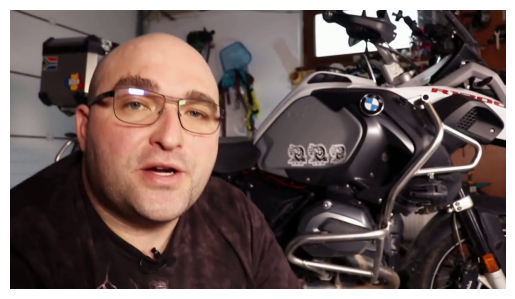

In [2]:
import os
import sys
sys.path.append("/workspace/src")
from ultralytics import YOLO
import cv2
from utils.video_utility import load_video, write_video, show_before_after
import matplotlib.pyplot as plt
import cv2

YOLO_PATH = "/workspace/weights/yolo/yolov8m.pt"
video_dir = "/workspace/data/videos"
video_paths = [f"{video_dir}/{file}" for file in os.listdir(video_dir) if file.endswith(".mp4")]
video_id = 4

# Load the YOLO model
yolo = YOLO(YOLO_PATH)

# Load the video
video_path = video_paths[video_id]
frames, fps, width, height = load_video(video_path)

print(f"video num = {len(frames)}")
print(f"video shape = {frames[0].shape}")


img = frames[0]
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")



In [3]:
results = yolo(img)

labels = []

for r in results:
    for cls, conf in zip(r.boxes.cls, r.boxes.conf):
        if conf > 0.4:
            label = yolo.names[int(cls)]
            labels.append(label)

labels = list(set(labels))
print(labels)


0: 384x640 1 person, 2 motorcycles, 37.4ms
Speed: 1.7ms preprocess, 37.4ms inference, 6.7ms postprocess per image at shape (1, 3, 384, 640)
['person', 'motorcycle']


class_names = ['person', 'motorcycle', 'motorcycle']
bbox_xys = [(2, 86, 1137, 1063), (788, 225, 1919, 1059), (1182, 2, 1919, 364)]
bbox_center_xy = [(569, 574), (1353, 642), (1550, 183)]
bbox_widths = [1135, 1131, 737]
bbox_lengths = [977, 834, 362]


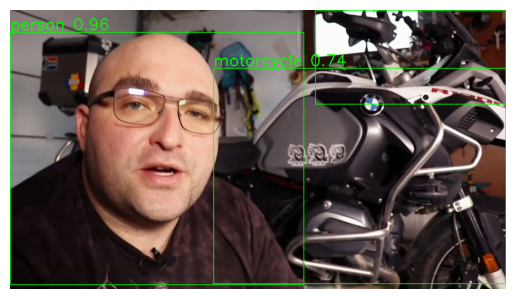

In [4]:
# img と bboxes を描画し、表示する
font_size = 2 # ラベルのfontサイズを指定する
text_thickness = 4 # ラベルのテキストの太さを指定する
rectangle_thickness = 2 # バウンディングボックスの線の太さを指定する
img_with_boxes = img.copy()

class_names = []
bbox_xys = []
bbox_center_xy = []
bbox_widths = []
bbox_lengths = []

for r in results:
    for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
        if conf > 0.4:
            x1, y1, x2, y2 = map(int, box)
            label = yolo.names[int(cls)]
            cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), (0, 255, 0), rectangle_thickness)
            cv2.putText(img_with_boxes, f"{label} {conf:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, font_size, (0, 255, 0), text_thickness)

            # クラス名、バウンディングボックスの中心座標、幅、高さを保存する
            class_names.append(label)
            bbox_xys.append((x1, y1, x2, y2))
            bbox_center_xy.append(((x1 + x2) // 2, (y1 + y2) // 2))
            bbox_widths.append(x2 - x1)
            bbox_lengths.append(y2 - y1)

img_with_boxes_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)
plt.imshow(img_with_boxes_rgb)
plt.axis("off")
print(f"class_names = {class_names}")
print(f"bbox_xys = {bbox_xys}")
print(f"bbox_center_xy = {bbox_center_xy}")
print(f"bbox_widths = {bbox_widths}")
print(f"bbox_lengths = {bbox_lengths}")

In [5]:
yolo.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [6]:
print(f"type(results) = {type(results)}")
print(f"len(results) = {len(results)}")

type(results) = <class 'list'>
len(results) = 1


In [7]:
print(f"results[0] = {results[0]}")

results[0] = ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'p

In [8]:
print(f"results[0].boxes = {results[0].boxes}")

results[0].boxes = ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 3., 3.], device='cuda:0')
conf: tensor([0.9588, 0.7435, 0.5681], device='cuda:0')
data: tensor([[2.5313e+00, 8.6491e+01, 1.1376e+03, 1.0630e+03, 9.5884e-01, 0.0000e+00],
        [7.8897e+02, 2.2564e+02, 1.9192e+03, 1.0597e+03, 7.4352e-01, 3.0000e+00],
        [1.1826e+03, 2.7289e+00, 1.9194e+03, 3.6451e+02, 5.6811e-01, 3.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 1920)
shape: torch.Size([3, 6])
xywh: tensor([[ 570.0526,  574.7554, 1135.0424,  976.5284],
        [1354.0842,  642.6532, 1130.2379,  834.0339],
        [1551.0095,  183.6174,  736.8110,  361.7769]], device='cuda:0')
xywhn: tensor([[0.2969, 0.5322, 0.5912, 0.9042],
        [0.7053, 0.5950, 0.5887, 0.7723],
        [0.8078, 0.1700, 0.3838, 0.3350]], device='cuda:0')
xyxy: tensor([[   2.5313,   86.4911, 1137.5737, 1063.0195],
        [ 788.9652,  225.6363, 1919.2031, 1059.6702],
        [1182.6040,    2.72

# 2. Depth Anything
- モデルの保存先: .cache/huggingface/hub/

In [9]:
# already satisfied
#!sudo python3 -m pip install transformers accelerate
#!sudo python3 -m pip install timm

In [10]:
import torch
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
from PIL import Image
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained("LiheYoung/depth-anything-small-hf")
depth_any = AutoModelForDepthEstimation.from_pretrained("LiheYoung/depth-anything-small-hf").to(device)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 287/287 [00:00<00:00, 16217.13it/s]


In [11]:
def get_depth(image_bgr):
    image = Image.fromarray(image_bgr[:, :, ::-1])  # BGR→RGB

    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = depth_any(**inputs)

    depth = outputs.predicted_depth[0].cpu().numpy()

    # normalize
    depth = (depth - depth.min()) / (depth.max() - depth.min())

    return depth

In [17]:
# --- YOLO ---
person_boxes = []

for r in results:
    for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
        if yolo.names[int(cls)] == "person" and conf > 0.4:
            person_boxes.append(tuple(map(int, box)))

# --- Depth ---
depth = get_depth(frames[0])
# resize（ここが重要）
depth_resized = cv2.resize(depth, (frames[0].shape[1], frames[0].shape[0]))

th = np.percentile(depth_resized, 70)

# 前景マスク
foreground_mask = depth_resized > th
background_mask = depth_resized <= th

# --- combine ---
fore_mask = np.zeros_like(foreground_mask)
# back_mask = np.zeros_like(background_mask)

for (x1, y1, x2, y2) in person_boxes:
    fore_mask[y1:y2, x1:x2] = foreground_mask[y1:y2, x1:x2] # foreground_mask を fore_mask にコピー
    # back_mask[y1:y2, x1:x2] = background_mask[y1:y2, x1:x2] # background_mask を back_mask にコピー
    
back_mask = ~fore_mask

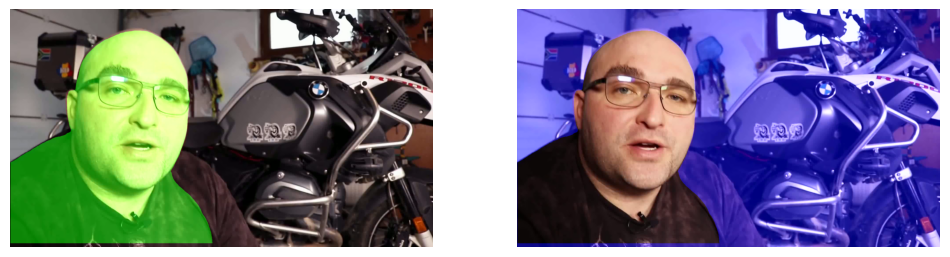

: 

In [ ]:
# final_mask を元の画像に重ねて表示する。
fore_mask_rgb = np.zeros_like(frames[0])
fore_mask_rgb[fore_mask] = [0, 255, 0]  # 緑色でマスクを表示

back_mask_rgb = np.zeros_like(frames[0])
back_mask_rgb[back_mask] = [255, 0, 0]  # 赤色でマスクを表示

fore_image = cv2.addWeighted(frames[0], 1, fore_mask_rgb, 0.5, 0)
back_image = cv2.addWeighted(frames[0], 1, back_mask_rgb, 0.5, 0)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(fore_image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(back_image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()
